In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import pandas as pd
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


Dataset Shape: (891, 12)

First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0       

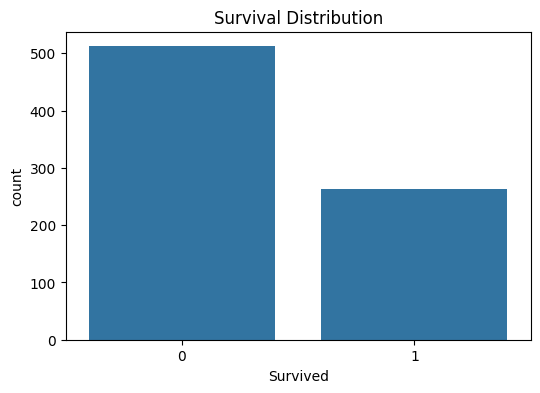

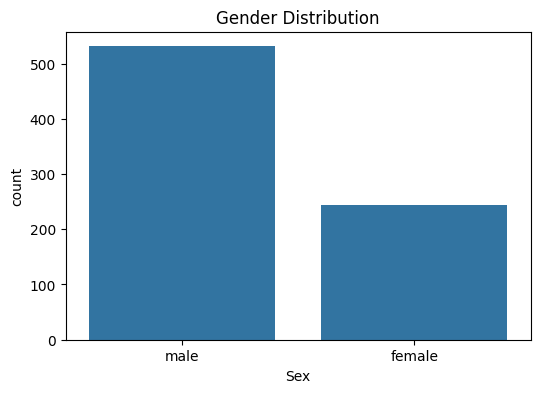

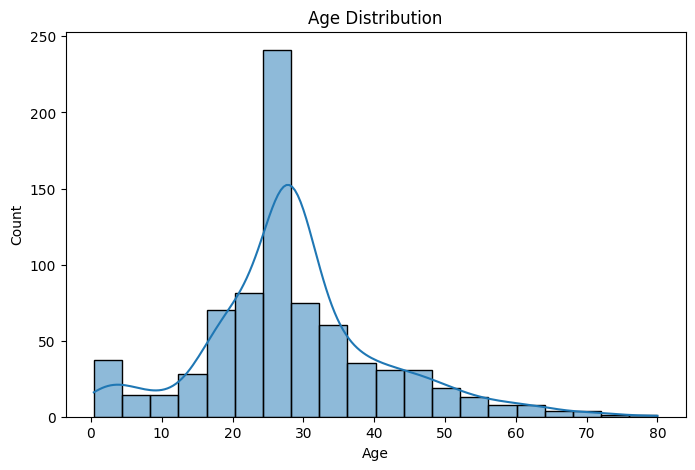

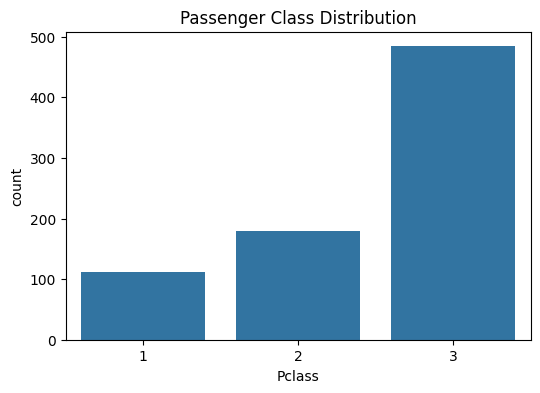

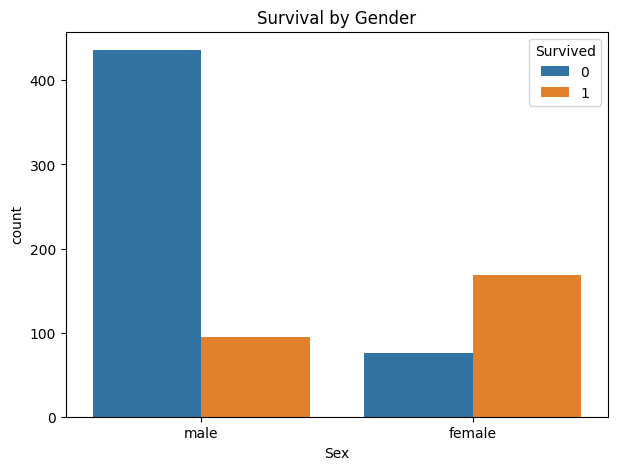

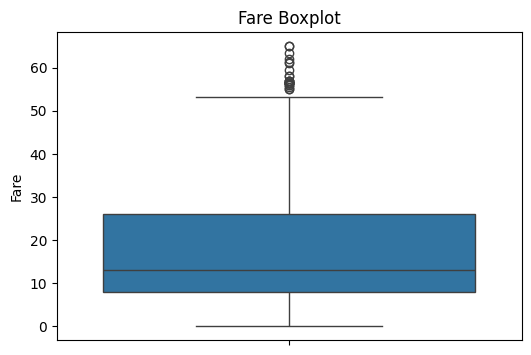

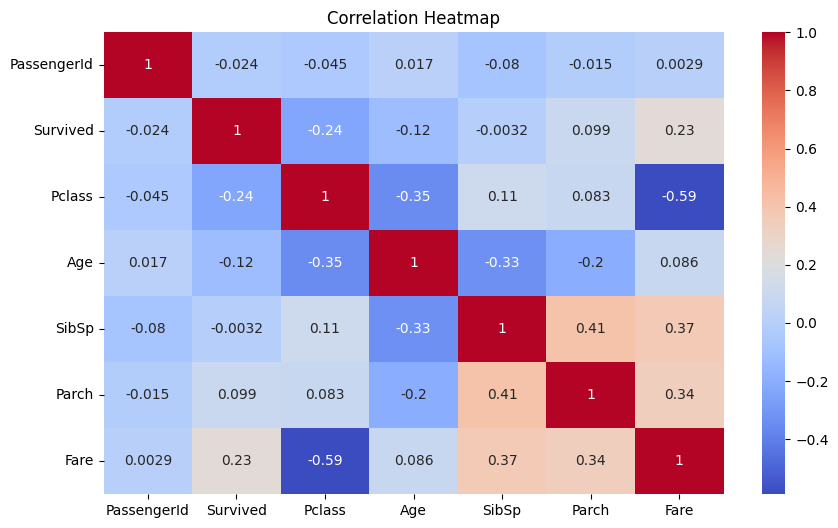


PROJECT INSIGHTS
Overall Survival Rate: 33.94%
Female Survival Rate: 68.85%
Male Survival Rate: 17.89%

Project Completed Successfully!
Cleaned dataset saved as cleaned_titanic.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

# -----------------------------
# DATA CLEANING
# -----------------------------

print("\nMissing Values:")
print(df.isnull().sum())

# Fill Missing Values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin Column
df.drop('Cabin', axis=1, inplace=True)

# Remove Duplicates
df.drop_duplicates(inplace=True)

print("\nAfter Cleaning:")
print(df.isnull().sum())

# -----------------------------
# OUTLIER REMOVAL
# -----------------------------

Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df['Fare'] >= lower) &
    (df['Fare'] <= upper)
]

# -----------------------------
# SUMMARY
# -----------------------------

print("\nSummary Statistics:")
print(df.describe())

# -----------------------------
# VISUALIZATION 1
# -----------------------------

plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title('Survival Distribution')
plt.show()

# -----------------------------
# VISUALIZATION 2
# -----------------------------

plt.figure(figsize=(6,4))
sns.countplot(x='Sex', data=df)
plt.title('Gender Distribution')
plt.show()

# -----------------------------
# VISUALIZATION 3
# -----------------------------

plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

# -----------------------------
# VISUALIZATION 4
# -----------------------------

plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', data=df)
plt.title('Passenger Class Distribution')
plt.show()

# -----------------------------
# VISUALIZATION 5
# -----------------------------

plt.figure(figsize=(7,5))
sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)

plt.title('Survival by Gender')
plt.show()

# -----------------------------
# VISUALIZATION 6
# -----------------------------

plt.figure(figsize=(6,4))
sns.boxplot(y=df['Fare'])
plt.title('Fare Boxplot')
plt.show()

# -----------------------------
# HEATMAP
# -----------------------------

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

# -----------------------------
# INSIGHTS
# -----------------------------

print("\nPROJECT INSIGHTS")

survival_rate = df['Survived'].mean() * 100

female_survival = (
    df[df['Sex']=='female']['Survived']
    .mean() * 100
)

male_survival = (
    df[df['Sex']=='male']['Survived']
    .mean() * 100
)

print(f"Overall Survival Rate: {survival_rate:.2f}%")
print(f"Female Survival Rate: {female_survival:.2f}%")
print(f"Male Survival Rate: {male_survival:.2f}%")

# Save Cleaned Data
df.to_csv('cleaned_titanic.csv', index=False)

print("\nProject Completed Successfully!")
print("Cleaned dataset saved as cleaned_titanic.csv")